In [1]:
import pathlib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
all_model_responses_dfs = []
for csv_response_file in pathlib.Path('../responses/speciesism-scale/').glob('**/*.csv'):
  model = csv_response_file.parent.stem
  with csv_response_file.open('r') as f:
    unmelted_responses_df = pd.read_csv(f, index_col=0).reset_index()
    unmelted_responses_df['5'] = 8 - unmelted_responses_df['5']
    model_responses_df = unmelted_responses_df.melt(
      id_vars=['trial_number'],
      var_name="question_number",
      value_name="answer",
    )
    model_responses_df['model'] = model
    model_responses_df = model_responses_df[['model', 'trial_number', 'question_number', 'answer']]
    all_model_responses_dfs.append(model_responses_df)

all_model_responses_df = pd.concat(all_model_responses_dfs)
all_model_responses_df

,model,trial_number,question_number,answer
0,gpt-4o,1,1,4
1,gpt-4o,2,1,2
2,gpt-4o,3,1,4
3,gpt-4o,4,1,2
4,gpt-4o,5,1,1
...,...,...,...,...
295,grok-3,46,6,5
296,grok-3,47,6,5
297,grok-3,48,6,5
298,grok-3,49,6,5


In [58]:
speciesism_scores_df = (
  all_model_responses_df
    .drop(columns=['question_number'])
    .groupby(['model', 'trial_number'])
    .mean()
    .reset_index()
    .rename(columns={'answer': 'speciesism_score'})
    .drop(columns=['trial_number'])
    .groupby(['model'])
    .agg(['mean', 'std'])
    .reset_index()
)
speciesism_scores_df.columns = ['_'.join(col).rstrip('_') for col in speciesism_scores_df.columns.values]
speciesism_scores_df

,model,speciesism_score_mean,speciesism_score_std
0,claude-3,2.466667,0.146772
1,deepseek-r1,1.840000,0.238000
2,gemini-1,2.116667,0.280205
3,gpt-4o,2.383333,0.284222
4,grok-3,2.493333,0.154156
5,llama-4-maverick,3.300000,0.315869
6,qwen-3,2.486667,0.380714


In [65]:
speciesism_scores_df.loc[len(speciesism_scores_df)] = ['women', 2.91, 1.26]
speciesism_scores_df.loc[len(speciesism_scores_df)] = ['men', 3.82, 1.30]
speciesism_scores_df

,model,speciesism_score_mean,speciesism_score_std
0,claude-3,2.466667,0.146772
1,deepseek-r1,1.840000,0.238000
2,gemini-1,2.116667,0.280205
3,gpt-4o,2.383333,0.284222
4,grok-3,2.493333,0.154156
5,llama-4-maverick,3.300000,0.315869
6,qwen-3,2.486667,0.380714
7,women,2.910000,1.260000
8,men,3.820000,1.300000


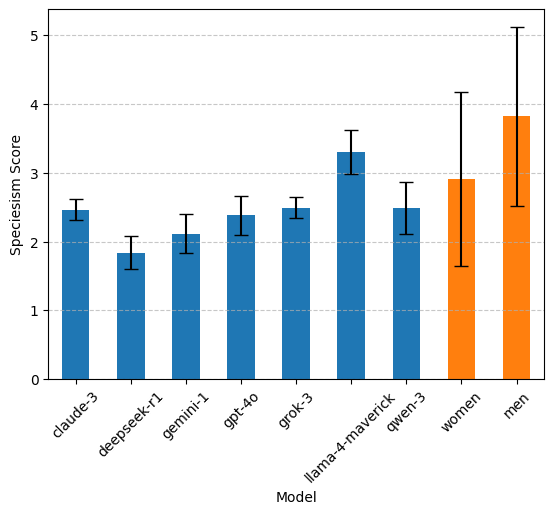

In [73]:
color_palette = sns.color_palette('tab10')
g = speciesism_scores_df.plot(
  x='model',
  y='speciesism_score_mean',
  yerr='speciesism_score_std',
  capsize=5,
  kind='bar',
  legend=False,
  rot=45,
  xlabel='Model',
  ylabel='Speciesism Score',
  color=[color_palette[model in ['women', 'men']] for model in speciesism_scores_df['model']],
)
g.grid(axis='y', linestyle='--', alpha=0.7)

In [75]:
g.figure.savefig('../plots/speciesism-scores.png', bbox_inches='tight', dpi=300)